## Hedging with Real SPX Option Data (SABR and Bartlett Deltas)

**Rate convention:** per-observation $r_t(\tau)$ via NSS (Assignment 1, Step 4). Dividend yield $q = 0$.

In [247]:
# all imports
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import ssl, urllib.request, warnings, os
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "font.size": 11})

Q_DIV = 0.0

## NSS Yield Curve Utilities (from Assignment 1, Step 4)

In [248]:
# NSS functions
def g1(tau, lam):
    x = np.asarray(tau/lam, dtype=float)
    return np.where(x<1e-10, 1.0, (1-np.exp(-x))/x)
 
def g2(tau, lam):
    return g1(tau, lam) - np.exp(-np.asarray(tau / lam, dtype=float))
 
def g3(tau, lam):
    return g1(tau, lam) - np.exp(-np.asarray(tau / lam, dtype=float))

def build_X_nss(tenors, tau1, tau2):
    m = np.array([max(t, 1/365) for t in tenors])
    X = np.ones((len(m), 4))
    X[:, 1] = g1(m, tau1)
    X[:, 2] = g2(m, tau1)
    X[:, 3] = g3(m, tau2)
    return X
 
# Fit NSS model for a single date
def fit_nss_one_date(y_t, tenors):
    tau1_grid = [0.5, 1, 1.5, 2, 3, 5]
    tau2_grid = [0.5, 1, 1.5, 2, 3, 5, 10, 15, 20]
    best_sse, best_beta, best_t1, best_t2 = np.inf, None, None, None
    for t1 in tau1_grid:
        for t2 in tau2_grid:
            if t2<=t1:
                continue
            X = build_X_nss(tenors, t1, t2)
            try:
                beta = np.linalg.solve(X.T@X, X.T@ y_t)
            except np.linalg.LinAlgError:
                continue
            sse = np.sum((y_t-X@beta)**2)
            if sse<best_sse:
                best_sse, best_beta, best_t1, best_t2 = sse, beta.copy(), t1, t2
    return best_beta, best_t1, best_t2

# Evaluating NSS model
def nss_eval(tau, beta, tau1, tau2):
    tau = np.maximum(np.asarray(tau, dtype=float), 1/365)
    return beta[0] + beta[1]*g1(tau,tau1) + beta[2]*g2(tau,tau1) + beta[3]*g3(tau,tau2)

## Step 1 — Data Loading and Cleaning

In [249]:
# Data Preprocessing
raw = pd.read_csv("option20230201_20230228.csv", low_memory=False)
print(f"Row count (raw): {len(raw):,}")
# Filtering for call options
rows_before = len(raw)
df = raw[raw["cp_flag"] == "C"].copy()
print(f"Rows before call filter : {rows_before:,}")
print(f"Rows after  call filter : {len(df):,}")
# Converting date columns to datetime
df["date"]   = pd.to_datetime(df["date"])
df["exdate"] = pd.to_datetime(df["exdate"])
# rescaling strike price
df["K"]      = df["strike_price"] / 1000.0
df["mid"]    = (df["best_bid"] + df["best_offer"]) / 2.0
df.rename(columns={"impl_volatility": "sigma_mkt", "delta": "delta_vendor"}, inplace=True)
# Dropping rows with missing or non-positive σ_mkt
n_before = len(df)
df = df[df["sigma_mkt"].notna() & (df["sigma_mkt"] > 0)].copy()
print(f"Dropped {n_before - len(df):,} rows with missing/non-positive σ_mkt → {len(df):,} remaining")
# Displaying unique dates
print(f"\nUnique trading dates : {df['date'].nunique()}")
print(f"Unique expiry  dates : {df['exdate'].nunique()}")
for col in ["mid", "sigma_mkt", "delta_vendor"]:
    print(f"  Missing rate  {col:>15s} : {df[col].isna().mean():.4%}")
# Calculating time-to-expiry
df["D_days"] = (df["exdate"] - df["date"]).dt.days
df["tau"]    = np.maximum(df["D_days"] / 365.0, 1/365)
# Selecting final columns
KEEP = ["date","exdate","symbol","K","mid","sigma_mkt","delta_vendor","D_days","tau","best_bid","best_offer","optionid"]
df = df[[c for c in KEEP if c in df.columns]].copy()
print(f"\nFinal columns: {list(df.columns)}")
print(f"Final row count: {len(df):,}")

Row count (raw): 175,301
Rows before call filter : 175,301
Rows after  call filter : 175,301
Dropped 21,573 rows with missing/non-positive σ_mkt → 153,728 remaining

Unique trading dates : 19
Unique expiry  dates : 67
  Missing rate              mid : 0.0000%
  Missing rate        sigma_mkt : 0.0000%
  Missing rate     delta_vendor : 0.0000%

Final columns: ['date', 'exdate', 'symbol', 'K', 'mid', 'sigma_mkt', 'delta_vendor', 'D_days', 'tau', 'best_bid', 'best_offer', 'optionid']
Final row count: 153,728


## Step 2 — Contract Time Series and One-Day Option Changes

In [250]:
# Calculating price changes
df.sort_values(["symbol", "date"], inplace=True)
df["mid_next"]  = df.groupby("symbol")["mid"].shift(-1)
df["date_next"] = df.groupby("symbol")["date"].shift(-1)
df["dV"]        = df["mid_next"] - df["mid"]
df = df[df["dV"].notna()].copy()
# printing results
print(f"Rows with valid ΔV : {len(df):,}")
print(f"Contracts retained : {df['symbol'].nunique():,}")
print(f"\nV (mid) summary:\n{df['mid'].describe().round(4)}")
print(f"\nΔV summary:\n{df['dV'].describe().round(4)}")

Rows with valid ΔV : 141,619
Contracts retained : 11,593

V (mid) summary:
count    141619.0000
mean        430.7542
std         578.5852
min           0.0250
25%          36.4000
50%         206.4500
75%         600.8500
max        4022.7000
Name: mid, dtype: float64

ΔV summary:
count    141619.0000
mean         -6.3157
std          27.1283
min        -170.3000
25%         -22.2000
50%          -2.1500
75%           5.1000
max          70.2000
Name: dV, dtype: float64


## Step 3 — Underlying SPX Merge and One-Day Changes

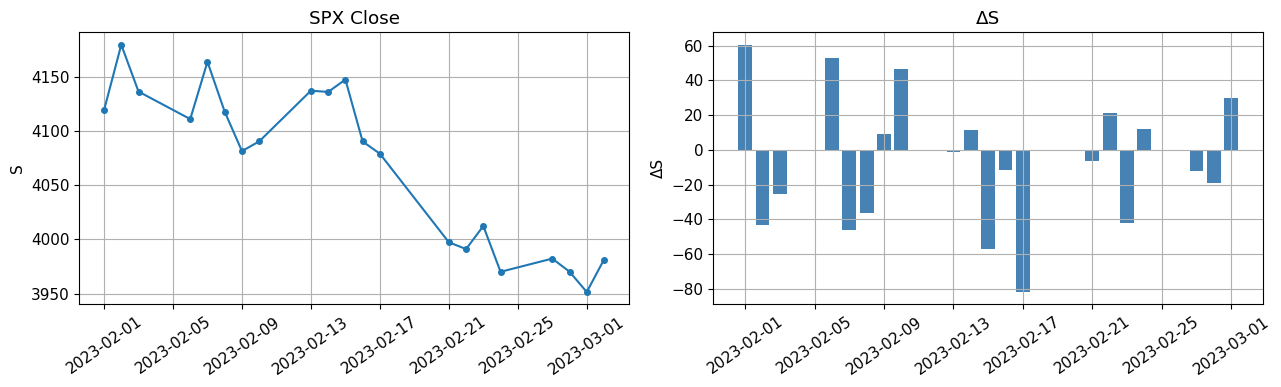

Merge coverage: 100.00%
S  summary:
count    141619.00
mean       4085.07
std          64.69
min        3970.04
25%        4012.32
50%        4090.46
75%        4136.48
max        4179.76
Name: S, dtype: float64
ΔS summary:
count    141619.0000
mean         -8.4770
std          37.8504
min         -81.7500
25%         -42.2800
50%         -11.3198
75%          12.2000
max          60.5498
Name: dS, dtype: float64
Rows after merge: 141,619
After one-day filter: 135,386 rows


In [251]:
# Downloading SPX data
import yfinance as yf

spx = yf.download("^GSPC", start="2023-02-01", end="2023-03-03", progress=False)
spx.columns = spx.columns.get_level_values(0)
spx = spx[["Close"]].reset_index().rename(columns={"Date":"date","Close":"S"})
spx["dS"] = spx["S"].shift(-1) - spx["S"]

# Plotting SPX close and one-day changes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(spx["date"], spx["S"], "o-", ms=4); axes[0].set_title("SPX Close"); axes[0].set_ylabel("S")
axes[1].bar(spx["date"], spx["dS"], width=0.8, color="steelblue"); axes[1].set_title("ΔS"); axes[1].set_ylabel("ΔS")
for ax in axes: ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.savefig("step3_spx.png", dpi=150); plt.show()

# Merging SPX closes into the option panel
df = df.merge(spx[["date","S","dS"]], on="date", how="left")
df = df[df["S"].notna() & df["dS"].notna()].copy()
print(f"Merge coverage: {df['S'].notna().mean():.2%}")
print(f"S  summary:\n{df['S'].describe().round(2)}")
print(f"ΔS summary:\n{df['dS'].describe().round(4)}")
print(f"Rows after merge: {len(df):,}")

# Ensuring ΔV and ΔS span the same one day trading step
trading_days = sorted(spx["date"].dropna().unique())
next_td = {trading_days[i]: trading_days[i+1] for i in range(len(trading_days)-1)}
df["expected_next"] = df["date"].map(next_td)
df = df[df["date_next"] == df["expected_next"]].copy()
df.drop(columns=["expected_next"], inplace=True)
print(f"After one-day filter: {len(df):,} rows")

### NSS Yield Curve: $r_t(\tau)$, Forward $F_t$, Discount $P_t$


In [252]:
# Fitting the NSS curve per trading date using US Treasury par yields, evaluating
# r_tau at each option's maturity, and computing F_t = S_t e^r_tau

# Mapping column names to tenors
COL_TO_TENOR = {
    "1 mo": 1/12, "2 mo": 2/12, "3 mo": 3/12, "6 mo": 6/12,
    "1 yr": 1, "2 yr": 2, "3 yr": 3, "5 yr": 5, "7 yr": 7,
    "10 yr": 10, "20 yr": 20, "30 yr": 30,
}
TENORS = list(COL_TO_TENOR.values())
# url for Treasury data
treasury_url = (
    "https://home.treasury.gov/resource-center/data-chart-center/interest-rates/"
    "daily-treasury-rate-archives/par-yield-curve-rates-2020-2023.csv"
)
# Downloading Treasury data
treasury_raw = pd.read_csv(treasury_url)
treasury_raw["date"] = pd.to_datetime(treasury_raw["date"]).dt.normalize()
treasury = treasury_raw[["date"]].copy()
for col, m in COL_TO_TENOR.items():
    if col in treasury_raw.columns:
        treasury[m] = pd.to_numeric(treasury_raw[col], errors="coerce") / 100
treasury = treasury.set_index("date").sort_index()
 
# Aligning to option trading dates via forward fill
opt_dates = pd.DatetimeIndex(sorted(df["date"].unique()))
treasury_aligned = treasury.reindex(opt_dates, method="ffill").bfill()
print(f"Treasury aligned to {len(opt_dates)} option dates, missing: {treasury_aligned[TENORS].isna().any(axis=1).sum()}")

Treasury aligned to 18 option dates, missing: 0


In [253]:
# Fitting NSS per date
nss_params_list = []
for i, (dt, row) in enumerate(treasury_aligned[TENORS].iterrows()):
    y_t = row.values
    beta, t1, t2 = fit_nss_one_date(y_t, TENORS)
    nss_params_list.append({"date": dt, "beta0": beta[0], "beta1": beta[1],
                            "beta2": beta[2], "beta3": beta[3], "nss_tau1": t1, "nss_tau2": t2})

nss_params = pd.DataFrame(nss_params_list)
print(f"NSS fitted for {len(nss_params)} dates")
 
# Merging NSS params, evaluating r_t(τ), and then computing F and P
df = df.merge(nss_params, on="date", how="left")
df["y_hat"] = (df["beta0"]
               + df["beta1"] * g1(df["tau"], df["nss_tau1"])
               + df["beta2"] * g2(df["tau"], df["nss_tau1"])
               + df["beta3"] * g3(df["tau"], df["nss_tau2"]))
df["r"] = 2*np.log(1+df["y_hat"]/2)   
df["P"] = np.exp(-df["r"] * df["tau"])
df["F"] = df["S"]*np.exp((df["r"] - Q_DIV)*df["tau"])
 
# Dropping intermediate NSS columns
df.drop(columns=["beta0","beta1","beta2","beta3","nss_tau1","nss_tau2","y_hat"], inplace=True)
 
print(f"\nr_t(τ) summary:\n{df['r'].describe().round(6)}")
print(f"\nAll r finite: {np.isfinite(df['r']).all()}")
print(f"All F finite: {np.isfinite(df['F']).all()}")

NSS fitted for 18 dates

r_t(τ) summary:
count    135386.000000
mean          0.046792
std           0.001873
min           0.034284
25%           0.045591
50%           0.046671
75%           0.048006
max           0.050769
Name: r, dtype: float64

All r finite: True
All F finite: True


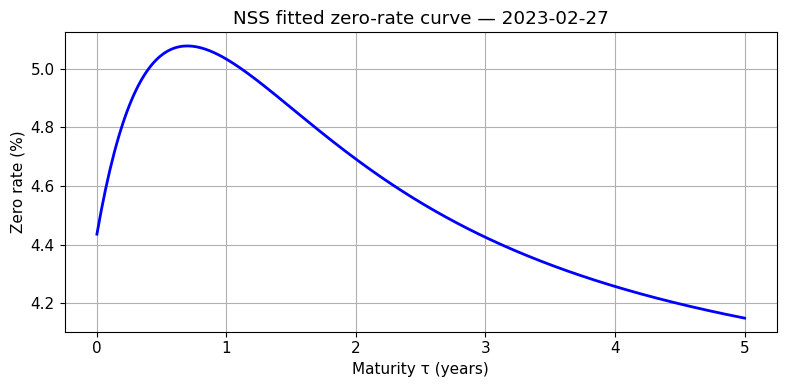

In [254]:
# Plotting fitted zero-rate curve for 2023-02-28
rep_date = pd.Timestamp("2023-02-28")
rep = nss_params[nss_params["date"] == rep_date]
if len(rep) == 0:
    rep = nss_params.iloc[[-1]]
b = rep.iloc[0]
tau_grid = np.linspace(1/365, 5, 300)
y_grid = nss_eval(tau_grid, [b["beta0"],b["beta1"],b["beta2"],b["beta3"]], b["nss_tau1"], b["nss_tau2"])
r_grid = 2 * np.log(1 + y_grid / 2)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tau_grid, r_grid * 100, "b-", lw=2)
ax.set_xlabel("Maturity τ (years)"); ax.set_ylabel("Zero rate (%)")
ax.set_title(f"NSS fitted zero-rate curve — {b['date'].date()}")
plt.tight_layout(); 
# plt.savefig("step3_nss_curve.png", dpi=150)
plt.show()

## Step 4 (Chunk A) — Baseline BS Delta Hedging

In [255]:
# Using per-observation r_t(tau) from NSS, q = 0
 
# black-scholes functions
def bs_d1(S, K, tau, sigma, r, q=0.0):
    return (np.log(S/K) + (r-q+0.5*sigma**2)*tau)/(sigma*np.sqrt(tau))
 
def bs_delta_call(S, K, tau, sigma, r, q=0.0):
    return np.exp(-q*tau)*norm.cdf(bs_d1(S, K, tau, sigma, r, q))
 
df["delta_bs"] = bs_delta_call(df["S"], df["K"], df["tau"], df["sigma_mkt"], df["r"], Q_DIV)
df["dS_hedge"] = df["dS"]   # q = 0 → hedge move = ΔS
df["eps_bs"] = df["dV"] - df["delta_bs"]*df["dS_hedge"]
 
print("Δ_BS summary:"); print(df["delta_bs"].describe().round(4))
print(f"\nε(Δ_BS) summary:"); print(df["eps_bs"].describe().round(4))

Δ_BS summary:
count    135386.0000
mean          0.5773
std           0.3480
min           0.0001
25%           0.2573
50%           0.6759
75%           0.8974
max           1.0000
Name: delta_bs, dtype: float64

ε(Δ_BS) summary:
count    135386.0000
mean         -0.2053
std           3.3842
min         -80.5217
25%          -2.6045
50%          -0.0470
75%           1.8771
max         100.9738
Name: eps_bs, dtype: float64


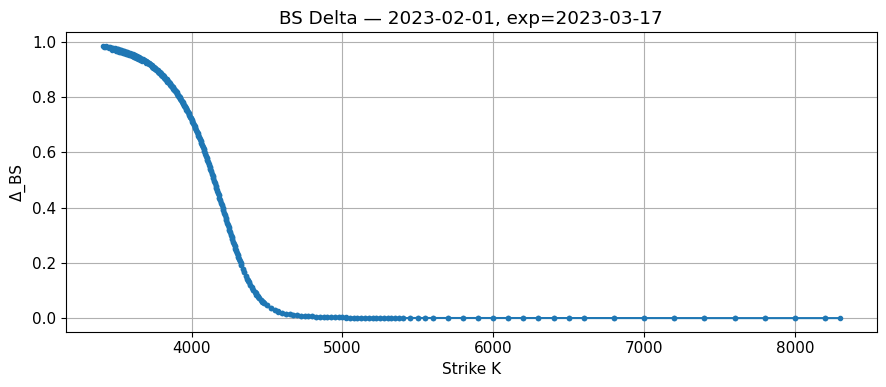

In [256]:
# Plotting BS delta vs strike for one slice
sd = df["date"].min()
se = df.loc[df["date"]==sd, "exdate"].mode().iloc[0]
sub = df[(df["date"]==sd) & (df["exdate"]==se)].sort_values("K")
 
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sub["K"], sub["delta_bs"], ".-")
ax.set_xlabel("Strike K"); ax.set_ylabel("Δ_BS")
ax.set_title(f"BS Delta — {sd.date()}, exp={se.date()}")
plt.tight_layout()
# plt.savefig("step4_bs_delta.png", dpi=150)
plt.show()

## Step 5 (Chunk B) — SABR Calibration ($\beta = 1$)


In [257]:
# Calibrating to all available strikes per (date, D) slice with $1<=D<=$200,
# using the market-consistent forward F_t

# SABR implied volatility function
def sabr_iv(K, F, tau, alpha, rho, nu):
    K = np.asarray(K, dtype=float); scalar=K.ndim==0; K=np.atleast_1d(K)
    iv = np.empty(len(K))
    tc = 1.0 + (rho*nu*alpha/4 + (2 - 3*rho**2)/24*nu**2)*tau
    # Calculating SABR implied volatility for each strike
    for i in range(len(K)):
        # Calculating the log-moneyness
        x = np.log(F/K[i])
        if abs(x) < 1e-12:
            # Log-moneyness is close to zero
            iv[i] = alpha*tc
        else:
            # Calculating the SABR implied volatility 
            # if log-moneyness is not close to zero
            z = (nu/alpha)*x
            xi = np.sqrt(1-2*rho*z+z**2)
            chi = np.log((xi+z-rho)/(1-rho))
            iv[i] = alpha*tc if abs(chi)<1e-14 else (nu*x/chi)*tc
    return float(iv[0]) if scalar else iv

# Calibrating SABR model
def calibrate_sabr(K_arr, sig_arr, F, tau):
    K_arr = np.asarray(K_arr, float); sig_arr = np.asarray(sig_arr, float)
    if len(K_arr) < 3:
        return np.nan, np.nan, np.nan, np.nan
    # Initializing parameters
    a0 = float(np.median(sig_arr))
    def obj(p):
        return np.nansum((sabr_iv(K_arr, F, tau, p[0], p[1], p[2]) - sig_arr)**2)
    # Setting bounds for the parameters
    bounds = [(1e-6, 2), (-0.999, 0.1), (1e-6, 3)]
    best = None
    # Trying different initial values
    for r0 in [-0.7, -0.3, 0.0]:
        for v0 in [0.2, 0.5, 1.0]:
            try:
                res = minimize(obj, [a0, r0, v0], bounds=bounds, method="L-BFGS-B", options={"maxiter": 500, "ftol": 1e-14})
                if best is None or res.fun < best.fun:
                    best = res
            except Exception:
                continue
    if best is None:
        return np.nan, np.nan, np.nan, np.nan
    a, r, v = best.x
    rmse = np.sqrt(np.nanmean((sabr_iv(K_arr, F, tau, a, r, v) - sig_arr)**2))
    return a, r, v, rmse

In [258]:
# Restricting to maturity slices with 1 ≤ D ≤ 200 as specified in Step 5(b)
calib_df = df[(df["D_days"] >= 1) & (df["D_days"]<=200)].copy()
groups = calib_df.groupby(["date", "D_days"])
total = len(groups)
print(f"Calibrating {total} (date, D) slices")

# Fitting (α, ρ, ν) per slice using all available strikes
calib_results = []
for idx, ((dt, D), grp) in enumerate(groups):
    a, r, v, rmse = calibrate_sabr(
        grp["K"].values, grp["sigma_mkt"].values,
        grp["F"].iloc[0], grp["tau"].iloc[0]
    )
    calib_results.append({
        "date": dt, "D_days": D, "tau": grp["tau"].iloc[0],
        "n_strikes": len(grp), "alpha": a, "rho": r, "nu": v, "vol_rmse": rmse,
    })
    if (idx+1)%50==0 or idx+1==total:
        print(f"  {idx+1}/{total}")

calib = pd.DataFrame(calib_results)
calib_valid = calib.dropna(subset=["alpha"])

# Reporting Step 5(e) diagnostics: |K|, α, ρ, ν, RMSE per calibrated slice
print(f"\nCalibrated: {len(calib_valid)}/{len(calib)}")
print(calib_valid[["alpha", "rho", "nu", "vol_rmse"]].describe().round(4))

Calibrating 608 (date, D) slices
  50/608
  100/608
  150/608
  200/608
  250/608
  300/608
  350/608
  400/608
  450/608
  500/608
  550/608
  600/608
  608/608

Calibrated: 608/608
          alpha       rho        nu  vol_rmse
count  608.0000  608.0000  608.0000  608.0000
mean     0.1755   -0.4305    2.2949    0.0216
std      0.0331    0.2535    0.6262    0.0401
min      0.1265   -0.9740    0.9799    0.0014
25%      0.1612   -0.6283    1.7597    0.0067
50%      0.1707   -0.4771    2.3402    0.0108
75%      0.1817   -0.3079    3.0000    0.0181
max      0.4885    0.1000    3.0000    0.3490


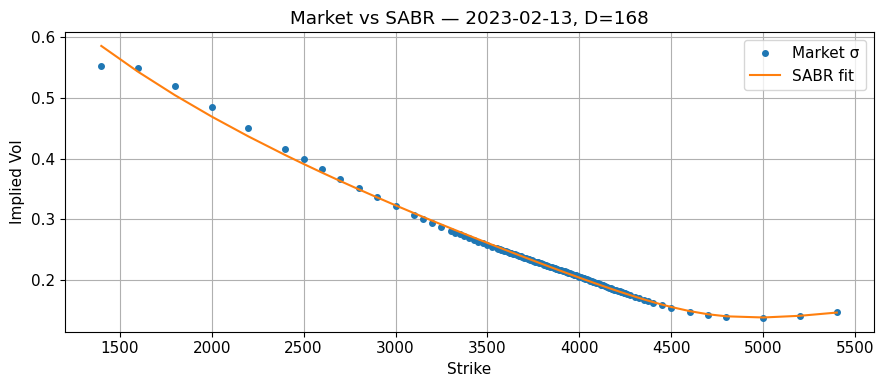

In [259]:
# Market smile vs SABR fitted smile
ss = calib_valid.iloc[len(calib_valid)//2]
sd, sD = ss["date"], int(ss["D_days"])
grp = calib_df[(calib_df["date"]==sd) & (calib_df["D_days"]==sD)].sort_values("K")
sig_fit = sabr_iv(grp["K"].values, grp["F"].iloc[0], grp["tau"].iloc[0], ss["alpha"], ss["rho"], ss["nu"])
 
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grp["K"], grp["sigma_mkt"], "o", ms=4, label="Market σ")
ax.plot(grp["K"], sig_fit, "-", lw=1.5, label="SABR fit")
ax.set_xlabel("Strike"); ax.set_ylabel("Implied Vol")
ax.set_title(f"Market vs SABR — {sd.date()}, D={sD}")
ax.legend()
plt.tight_layout()
# plt.savefig("step5_smile_fit.png", dpi=150)
plt.show()

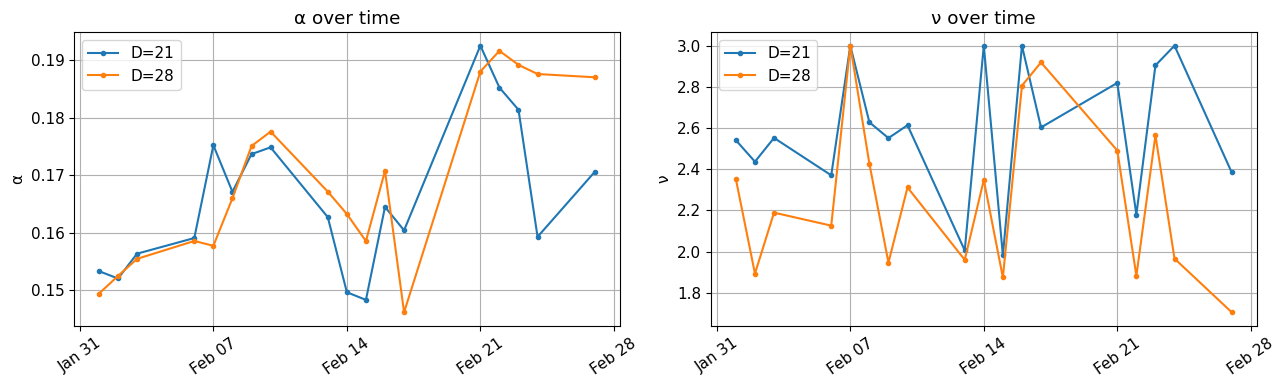

In [260]:
import matplotlib.dates as mdates

# Time series of α and ν for two maturities
top_D = calib_valid["D_days"].value_counts().head(2).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for dv in top_D:
    s = calib_valid[calib_valid["D_days"]==dv].sort_values("date")
    axes[0].plot(s["date"], s["alpha"], "o-", ms=3, label=f"D={dv}")
    axes[1].plot(s["date"], s["nu"],    "o-", ms=3, label=f"D={dv}")
axes[0].set_ylabel("α")
axes[0].set_title("α over time")
axes[0].legend()
axes[1].set_ylabel("ν"); axes[1].set_title("ν over time"); axes[1].legend()
for ax in axes:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
# plt.savefig("step5_alpha_nu_ts.png", dpi=150)
plt.show()

Calibration RMSE summary:
count    608.000000
mean       0.021556
std        0.040063
min        0.001362
25%        0.006655
50%        0.010805
75%        0.018134
max        0.348983
Name: vol_rmse, dtype: float64


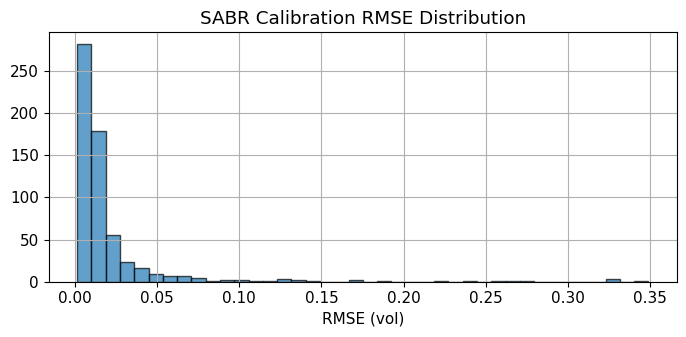

In [261]:
# Calibration error analysis
print("Calibration RMSE summary:")
print(calib_valid["vol_rmse"].describe().round(6))
 
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(calib_valid["vol_rmse"].dropna(), bins=40, edgecolor="k", alpha=0.7)
ax.set_xlabel("RMSE (vol)"); ax.set_title("SABR Calibration RMSE Distribution")
plt.tight_layout()
# plt.savefig("step5_rmse_hist.png", dpi=150)
plt.show()

In [262]:
# Per-observation calibration error across the full (t, D, K) grid
calib_df = calib_df.merge(calib_valid[["date","D_days","alpha","rho","nu"]], on=["date","D_days"], how="left")
mask = calib_df["alpha"].notna()
calib_obs = calib_df[mask].copy()
calib_obs["sigma_sabr"] = calib_obs.apply(
    lambda r: sabr_iv(r["K"], r["F"], r["tau"], r["alpha"], r["rho"], r["nu"]), axis=1)
calib_obs["vol_err"] = calib_obs["sigma_sabr"] - calib_obs["sigma_mkt"]

mae  = calib_obs["vol_err"].abs().mean()
mse  = (calib_obs["vol_err"]**2).mean()
rmse = np.sqrt(mse)

print(f"Calibration error across {len(calib_obs):,} (t, D, K) observations:")
print(f"  MAE  = {mae:.6f}")
print(f"  MSE  = {mse:.10f}")
print(f"  RMSE = {rmse:.6f}")
print(f"\nError distribution:")
print(calib_obs["vol_err"].describe().round(6))

Calibration error across 110,806 (t, D, K) observations:
  MAE  = 0.014302
  MSE  = 0.0020648930
  RMSE = 0.045441

Error distribution:
count    110806.000000
mean          0.000293
std           0.045440
min          -1.593314
25%          -0.004643
50%          -0.000289
75%           0.006794
max           0.290884
Name: vol_err, dtype: float64


### Step 6 (Chunk C) — SABR & Bartlett Deltas, Filters, Buckets, Gains

In [263]:
# Merging SABR calibration results with the main DataFrame
df = df.merge(calib[["date","D_days","alpha","rho","nu","vol_rmse"]],on=["date","D_days"], how="left")
print(f"Rows with valid SABR: {df['alpha'].notna().sum():,} / {len(df):,}")

Rows with valid SABR: 110,806 / 135,386


**Differentiation method:** Central differences with step sizes $h_F = 10^{-4}F_t$
and $h_\alpha = 10^{-4}\hat\alpha$, as specified in Step 6(b–c).

In [264]:
# Computing Black forward-form Greeks: ∂B/∂F and ∂B/∂σ
def bs_greeks(F, K, tau, sigma, r):
    sqt  = sigma*np.sqrt(tau)
    d1   = (np.log(F/K)+0.5*sigma**2*tau)/sqt
    dBdF = np.exp(-r*tau)*norm.cdf(d1)
    dBds = np.exp(-r*tau)*F*np.sqrt(tau)*norm.pdf(d1)
    return dBdF, dBds

# Computing SABR and Bartlett deltas for a single observation
def comp_deltas(row):
    F, K, tau = row["F"], row["K"], row["tau"]
    alpha, rho, nu = row["alpha"], row["rho"], row["nu"]
    r_val = row["r"]
    if np.isnan(alpha):
        return np.nan, np.nan

    # Evaluating SABR implied vol at calibrated parameters
    sig = sabr_iv(K, F, tau, alpha, rho, nu)
    if np.isnan(sig) or sig<=0:
        return np.nan, np.nan

    dBdF, dBds = bs_greeks(F, K, tau, sig, r_val)

    # Approximating ∂σ_imp/∂F via central differences (h_F = 10⁻⁴·F)
    hF = 1e-4*F
    dsig_dF = (sabr_iv(K, F+hF, tau, alpha, rho, nu)-sabr_iv(K, F-hF, tau, alpha, rho, nu))/(2*hF)

    # Approximating ∂σ_imp/∂α via central differences (h_α = 10⁻⁴·α)
    ha = 1e-4*alpha
    dsig_da = (sabr_iv(K, F, tau, alpha+ha, rho, nu)-sabr_iv(K, F, tau, alpha-ha, rho, nu))/(2*ha)

    # Converting forward-based deltas to spot-based hedge ratios (× e^{(r-q)τ})
    fac = np.exp((r_val-Q_DIV)*tau)
    d_sabr = fac*(dBdF+dBds*dsig_dF)
    d_bart = fac*(dBdF+dBds*(dsig_dF+dsig_da*rho*nu/F))
    return d_sabr, d_bart

In [265]:
print("Computing SABR and Bartlett deltas")
res = df.apply(comp_deltas, axis=1, result_type="expand")
df["delta_sabr"] = res[0]
df["delta_bart"] = res[1]
print(f"  SABR  valid: {df['delta_sabr'].notna().sum():,}")
print(f"  Bart  valid: {df['delta_bart'].notna().sum():,}")
 

Computing SABR and Bartlett deltas
  SABR  valid: 110,806
  Bart  valid: 110,806


### Concept Questions

**Role of ρ in the skew adjustment:**
The parameter ρ controls how the underlying's returns and its volatility move together.
In the Bartlett delta, this shows up through the extra correction term involving
∂σ/∂α · ρν/F , essentially adjusting the hedge for the fact that when the spot moves,
volatility moves too. If ρ is large in magnitude, ignoring this co-movement leads to
a systematically biased hedge. The Bartlett delta corrects for this by incorporating
the optimal amount of vega exposure into the delta, which is exactly what
variance optimal hedging prescribes under stochastic volatility.

**Expected sign for SPX:**
For equity indices like the SPX, we expect ρ to be negative. This reflects the leverage effect, when the index drops, realised and
implied volatility tend to spike.

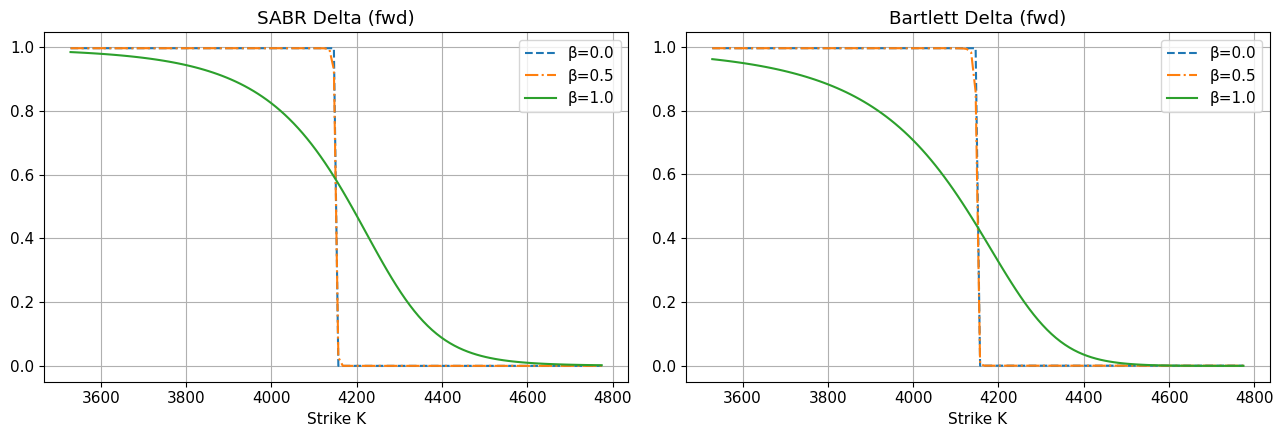

In [266]:
# Computing general SABR implied vol for arbitrary β (Hagan approximation)
def sabr_iv_gen(K, F, tau, alpha, rho, nu, beta):
    K = np.asarray(K, float); sc = K.ndim==0; K = np.atleast_1d(K)
    iv = np.empty(len(K))
    for i in range(len(K)):
        k = K[i]; x = np.log(F/k); fk = F*k
        I1 = (alpha**2*(1-beta)**2/(24*fk**(1-beta))
              +alpha*beta*rho*nu/(4*fk**((1-beta)/2))
              +(2-3*rho**2)/24*nu**2)
        if abs(x) < 1e-12:
            iv[i] = alpha*k**(beta-1)*(1+I1*tau)
        else:
            z = (nu/alpha)*(F**(1-beta)-k**(1-beta))/(1-beta) if abs(beta-1)>1e-12 else (nu/alpha)*x
            xi = np.sqrt(1-2*rho*z+z**2)
            chi = np.log((xi+z-rho)/(1-rho))
            iv[i] = alpha*k**(beta-1)*(1+I1*tau) if abs(chi)<1e-14 else (nu*x/chi)*(1+I1*tau)
    return float(iv[0]) if sc else iv

# Plotting the effect of β on SABR and Bartlett deltas for one slice
mv = df["alpha"].notna() & (df["D_days"]>=20) & (df["D_days"]<=60)
if mv.sum() > 0:
    ref = df[mv].iloc[len(df[mv])//2]
    F_p, tau_p, a_p, r_p, v_p, rv = ref["F"], ref["tau"], ref["alpha"], ref["rho"], ref["nu"], ref["r"]
    Ks = np.linspace(F_p*0.85, F_p*1.15, 120)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for bv, ls in [(0.0,"--"),(0.5,"-."),(1.0,"-")]:
        ds, db = [], []
        for kk in Ks:
            sv = sabr_iv_gen(kk, F_p, tau_p, a_p, r_p, v_p, bv)
            if np.isnan(sv) or sv<=0: ds.append(np.nan); db.append(np.nan); continue
            g1_, g2_ = bs_greeks(F_p, kk, tau_p, sv, rv)
            # Computing ∂σ/∂F and ∂σ/∂α via central differences
            hF = 1e-4*F_p
            dF_ = (sabr_iv_gen(kk,F_p+hF,tau_p,a_p,r_p,v_p,bv)-sabr_iv_gen(kk,F_p-hF,tau_p,a_p,r_p,v_p,bv))/(2*hF)
            ha = 1e-4*a_p
            da_ = (sabr_iv_gen(kk,F_p,tau_p,a_p+ha,r_p,v_p,bv)-sabr_iv_gen(kk,F_p,tau_p,a_p-ha,r_p,v_p,bv))/(2*ha)
            ds.append(g1_+g2_*dF_)
            db.append(g1_+g2_*(dF_+da_*r_p*v_p/F_p**bv))
        axes[0].plot(Ks, ds, ls=ls, label=f"β={bv}")
        axes[1].plot(Ks, db, ls=ls, label=f"β={bv}")
    axes[0].set_title("SABR Delta (fwd)"); axes[1].set_title("Bartlett Delta (fwd)")
    for ax in axes: ax.set_xlabel("Strike K"); ax.legend()
    plt.tight_layout()
    # plt.savefig("step6_beta_comparison.png", dpi=150)
    plt.show()

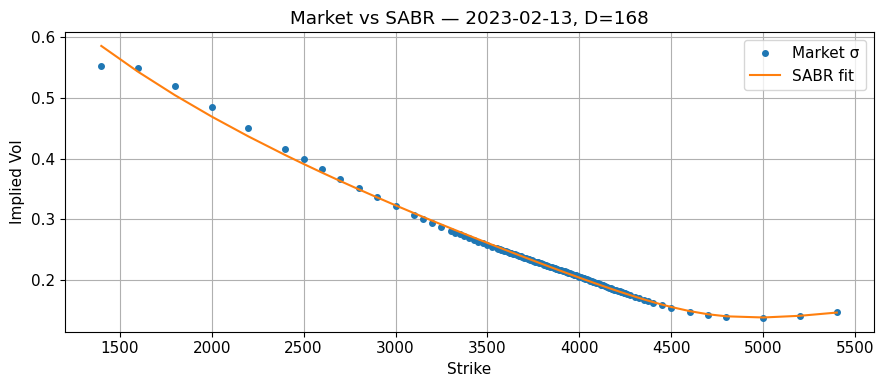

In [267]:
# Market smile vs SABR fitted smile
ss = calib_valid.iloc[len(calib_valid)//2]
sd, sD = ss["date"], int(ss["D_days"])
grp = calib_df[(calib_df["date"]==sd) & (calib_df["D_days"]==sD)].sort_values("K")
sig_fit = sabr_iv(grp["K"].values, grp["F"].iloc[0], grp["tau"].iloc[0], ss["alpha"], ss["rho"], ss["nu"])
 
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grp["K"], grp["sigma_mkt"], "o", ms=4, label="Market σ")
ax.plot(grp["K"], sig_fit, "-", lw=1.5, label="SABR fit")
ax.set_xlabel("Strike"); ax.set_ylabel("Implied Vol")
ax.set_title(f"Market vs SABR — {sd.date()}, D={sD}")
ax.legend()
plt.tight_layout()
# plt.savefig("step5_smile_fit.png", dpi=150)
plt.show()

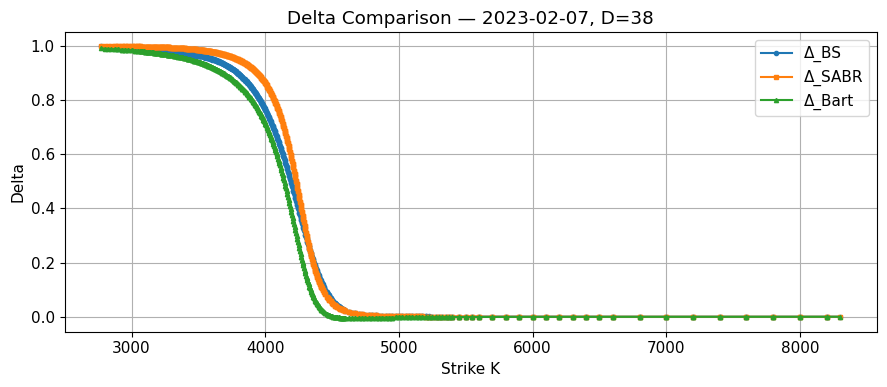

In [268]:
# Plotting Δ_BS, Δ_SABR, Δ_Bart vs strike for one slice
mp = df["delta_sabr"].notna() & (df["D_days"]>=20) & (df["D_days"]<=60)
if mp.sum() > 0:
    ref = df[mp].iloc[0]
    sl = df[(df["date"]==ref["date"])&(df["D_days"]==ref["D_days"])&df["delta_sabr"].notna()].sort_values("K")
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(sl["K"], sl["delta_bs"],   "o-", ms=3, label="Δ_BS")
    ax.plot(sl["K"], sl["delta_sabr"], "s-", ms=3, label="Δ_SABR")
    ax.plot(sl["K"], sl["delta_bart"], "^-", ms=3, label="Δ_Bart")
    ax.set_xlabel("Strike K"); ax.set_ylabel("Delta")
    ax.set_title(f"Delta Comparison — {ref['date'].date()}, D={int(ref['D_days'])}")
    ax.legend(); plt.tight_layout()
    # plt.savefig("step6_delta_comparison.png", dpi=150)
    plt.show()

### Standardised Filters, Bucketing, SSE/MSE, Gains

In [269]:
# Applying standardised filters (Step 6d)
n0 = len(df)
df_f = df[(df["delta_bs"]>0.05) & (df["delta_bs"]<0.95)].copy()
print(f"After Δ_BS ∈ (0.05, 0.95) : {len(df_f):,}  (dropped {n0-len(df_f):,})")

n1 = len(df_f)
df_f = df_f[df_f["D_days"]>14]
print(f"After D > 14              : {len(df_f):,}  (dropped {n1-len(df_f):,})")

n2 = len(df_f)
df_f = df_f[df_f["delta_sabr"].notna() & df_f["delta_bart"].notna()]
print(f"After SABR validity       : {len(df_f):,}  (dropped {n2-len(df_f):,})")

# Computing hedging residuals ε_t = ΔV_t − δ_t · ΔS^hedge_t for all three deltas
df_f["eps_bs"]   = df_f["dV"]-df_f["delta_bs"]*df_f["dS_hedge"]
df_f["eps_sabr"] = df_f["dV"]-df_f["delta_sabr"]*df_f["dS_hedge"]
df_f["eps_bart"] = df_f["dV"]-df_f["delta_bart"]*df_f["dS_hedge"]

# Computing total SSE, MSE, and Gains on the filtered sample
n_obs    = len(df_f)
sse_bs   = np.nansum(df_f["eps_bs"]**2)
sse_sabr = np.nansum(df_f["eps_sabr"]**2)
sse_bart = np.nansum(df_f["eps_bart"]**2)
mse_bs   = sse_bs/n_obs; mse_sabr = sse_sabr/n_obs; mse_bart = sse_bart/n_obs

g_sv = 1-sse_sabr/sse_bs
g_bv = 1-sse_bart/sse_bs
rg   = 1-sse_bart/sse_sabr

print(f"\n{'':>22s}  {'BS':>12s}  {'SABR':>12s}  {'Bartlett':>12s}")
print("-"*65)
print(f"{'SSE':>22s}  {sse_bs:12.2f}  {sse_sabr:12.2f}  {sse_bart:12.2f}")
print(f"{'MSE':>22s}  {mse_bs:12.6f}  {mse_sabr:12.6f}  {mse_bart:12.6f}")
print(f"\nGain(SABR vs BS)      = {g_sv:+.4%}")
print(f"Gain(Bart vs BS)      = {g_bv:+.4%}")
print(f"RelGain(Bart vs SABR) = {rg:+.4%}")
print(f"\n★ Competition Score = {g_bv:.6f}")

After Δ_BS ∈ (0.05, 0.95) : 96,485  (dropped 38,901)
After D > 14              : 85,914  (dropped 10,571)
After SABR validity       : 68,097  (dropped 17,817)

                                  BS          SABR      Bartlett
-----------------------------------------------------------------
                   SSE     750745.18    1586881.28     987061.10
                   MSE     11.024644     23.303248     14.494928

Gain(SABR vs BS)      = -111.3742%
Gain(Bart vs BS)      = -31.4775%
RelGain(Bart vs SABR) = +37.7987%

★ Competition Score = -0.314775


In [270]:
print(f"\nε(Δ_BS)   summary:\n{df_f['eps_bs'].describe().round(4)}")
print(f"\nε(Δ_SABR) summary:\n{df_f['eps_sabr'].describe().round(4)}")
print(f"\nε(Δ_Bart) summary:\n{df_f['eps_bart'].describe().round(4)}")


ε(Δ_BS)   summary:
count    68097.0000
mean        -0.4663
std          3.2875
min         -9.2097
25%         -3.2888
50%         -0.4401
75%          2.0117
max          9.3844
Name: eps_bs, dtype: float64

ε(Δ_SABR) summary:
count    68097.0000
mean         0.0956
std          4.8264
min        -10.3525
25%         -3.4125
50%         -0.4323
75%          2.9759
max         18.0553
Name: eps_sabr, dtype: float64

ε(Δ_Bart) summary:
count    68097.0000
mean        -1.1517
std          3.6289
min        -10.1820
25%         -3.6202
50%         -1.7746
75%          0.9313
max         11.5703
Name: eps_bart, dtype: float64


In [271]:
print(f"\nBaseline SSE(Δ_BS) after Step 6 filters = {sse_bs:.2f}")
print(f"Baseline MSE(Δ_BS) after Step 6 filters = {mse_bs:.6f}")


Baseline SSE(Δ_BS) after Step 6 filters = 750745.18
Baseline MSE(Δ_BS) after Step 6 filters = 11.024644


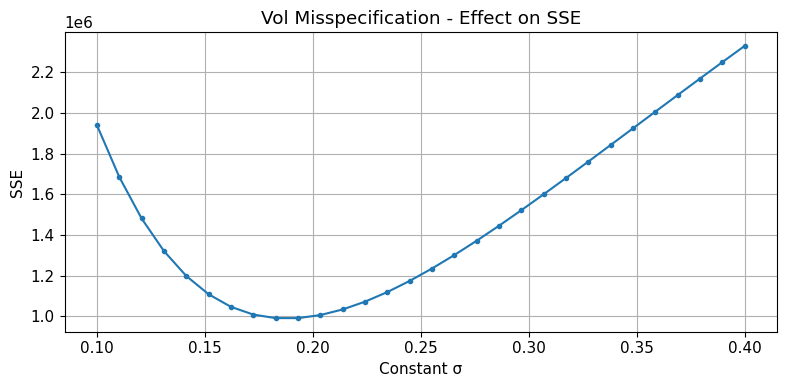

In [272]:
# Volatility misspecification experiment
sigma_grid = np.linspace(0.10, 0.40, 30)
sse_grid = [np.nansum((df_f["dV"] - bs_delta_call(df_f["S"],df_f["K"],df_f["tau"],s,df_f["r"],Q_DIV)*df_f["dS_hedge"])**2)
            for s in sigma_grid]
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sigma_grid, sse_grid, "o-", ms=3)
ax.set_xlabel("Constant σ"); ax.set_ylabel("SSE")
ax.set_title("Vol Misspecification - Effect on SSE")
plt.tight_layout()
# plt.savefig("step4_vol_misspec.png", dpi=150)
plt.show()

### Volatility Misspecification Discussion

The SSE curve is U-shaped with a minimum near σ ≈ 0.18–0.19, close to the average
market-implied volatility across the filtered panel. Hedging with a σ that is too low
or too high increases SSE, confirming the hedge ratio's sensitivity to the volatility
input. This is an empirical counterpart of the gamma-weighted P&L result from
Assignment 1 (Eq. 6), hedging error is minimised when the implied vol used for
hedging best approximates the realised volatility, weighted by dollar gamma.

In [273]:
# Creating 9 moneyness bins (by Δ_BS) and 7 maturity bins (by D_days) 
d_edges = [0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]  
D_edges = [14, 30, 60, 90, 120, 150, 180, 200]                            

df_f["bin1"] = pd.cut(df_f["delta_bs"], bins=d_edges, labels=range(1, len(d_edges)))
df_f["bin2"] = pd.cut(df_f["D_days"],   bins=D_edges, labels=range(1, len(D_edges)))
df_f = df_f.dropna(subset=["bin1","bin2"])
df_f["bin1"] = df_f["bin1"].astype(int)
df_f["bin2"] = df_f["bin2"].astype(int)

# Computing bucketed SSE/MSE/Gain for each (bin1, bin2) pair
rows = []
for (b1, b2), g in df_f.groupby(["bin1","bin2"]):
    n = len(g)
    sb = np.nansum(g["eps_bs"]**2); ss = np.nansum(g["eps_sabr"]**2); st = np.nansum(g["eps_bart"]**2)
    rows.append({"section":"BUCKET", "bin1":int(b1), "bin2":int(b2), "n_obs":n,
                 "sse_bs":sb, "sse_sabr":ss, "sse_bartlett":st,
                 "mse_bs":sb/n, "mse_sabr":ss/n, "mse_bartlett":st/n,
                 "gain_sabr_vs_bs":1-ss/sb if sb>0 else np.nan,
                 "gain_bart_vs_bs":1-st/sb if sb>0 else np.nan,
                 "relgain_bart_vs_sabr":1-st/ss if ss>0 else np.nan})

# Appending TOTAL row
rows.append({"section":"TOTAL", "bin1":"TOTAL", "bin2":"TOTAL", "n_obs":n_obs,
             "sse_bs":sse_bs, "sse_sabr":sse_sabr, "sse_bartlett":sse_bart,
             "mse_bs":mse_bs, "mse_sabr":mse_sabr, "mse_bartlett":mse_bart,
             "gain_sabr_vs_bs":g_sv, "gain_bart_vs_bs":g_bv, "relgain_bart_vs_sabr":rg})

scoreboard = pd.DataFrame(rows)
 

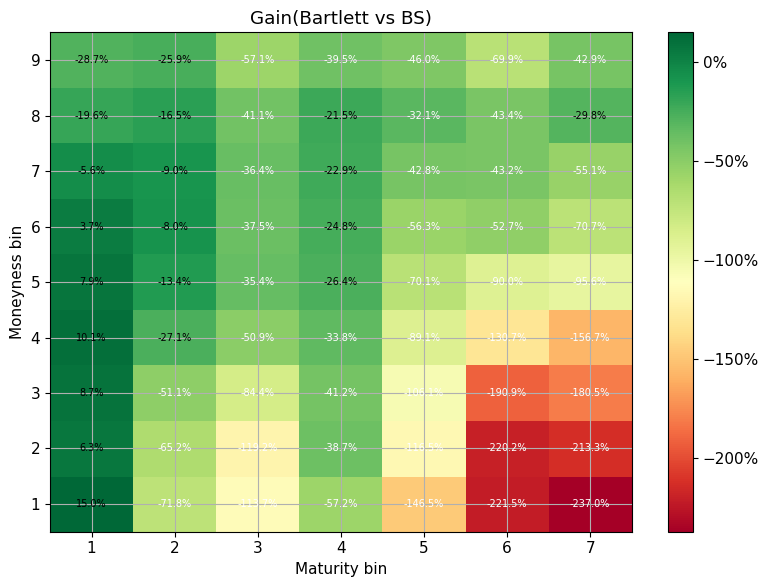

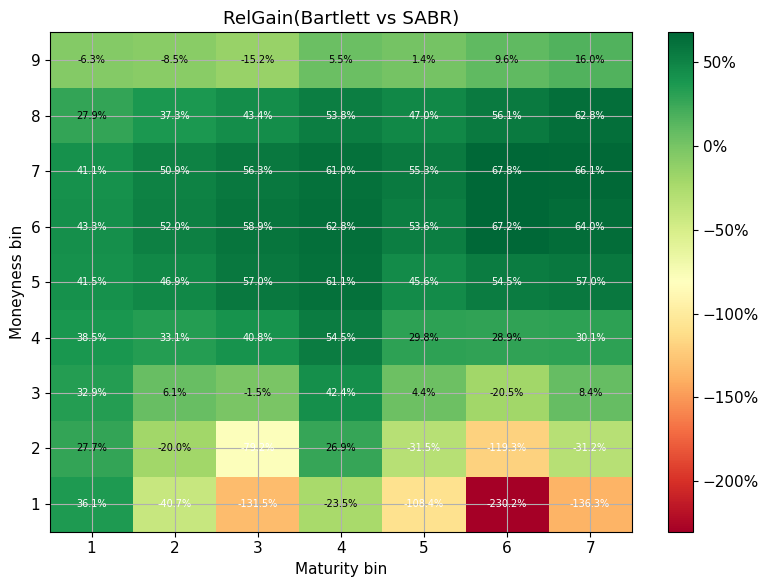

In [274]:
# Plotting gain heatmaps across the 9×7 bucket grid
def gain_heatmap(sb, col, title, fn):
    bk = sb[sb["section"]=="BUCKET"].copy()
    bk["bin1"]=bk["bin1"].astype(int); bk["bin2"]=bk["bin2"].astype(int)
    piv = bk.pivot(index="bin1", columns="bin2", values=col)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(piv.values, aspect="auto", cmap="RdYlGn", origin="lower")
    ax.set_xticks(range(piv.shape[1]))
    ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(piv.shape[0]))
    ax.set_yticklabels(piv.index)
    ax.set_xlabel("Maturity bin")
    ax.set_ylabel("Moneyness bin"); ax.set_title(title)
    # Annotating each cell with its gain percentage
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i,j]
            if not np.isnan(v):
                ax.text(j,i,f"{v:.1%}",ha="center",va="center",fontsize=7,
                        color="black" if abs(v)<0.3 else "white")
    plt.colorbar(im, ax=ax, format=mticker.PercentFormatter(1.0))
    plt.tight_layout()
    # plt.savefig(fn, dpi=150)
    plt.show()

# Generating Gain(Bart vs BS) and RelGain(Bart vs SABR) heatmaps
gain_heatmap(scoreboard, "gain_bart_vs_bs", "Gain(Bartlett vs BS)", "step6_gain_bart_bs.png")
gain_heatmap(scoreboard, "relgain_bart_vs_sabr", "RelGain(Bartlett vs SABR)", "step6_relgain_bart_sabr.png")

### Step 7 — Standardised Competition Outputs
 

In [275]:
# Exporting CalibrationMetrics.csv, one row per calibrated (t, D) slice
calib_valid[["date","D_days","tau","n_strikes","alpha","rho","nu","vol_rmse"]].to_csv(
    "CalibrationMetrics.csv", index=False)
print(f"CalibrationMetrics.csv → {len(calib_valid):,} rows")

# Exporting HedgingScoreboard.csv — tidy long format with BUCKET and TOTAL rows
cols = ["section","bin1","bin2","n_obs",
        "sse_bs","sse_sabr","sse_bartlett",
        "mse_bs","mse_sabr","mse_bartlett",
        "gain_sabr_vs_bs","gain_bart_vs_bs","relgain_bart_vs_sabr"]
scoreboard[cols].to_csv("HedgingScoreboard.csv", index=False)
print(f"HedgingScoreboard.csv → {len(scoreboard):,} rows")
print(scoreboard[cols].to_string(index=False))

CalibrationMetrics.csv → 608 rows
HedgingScoreboard.csv → 64 rows
section  bin1  bin2  n_obs        sse_bs     sse_sabr  sse_bartlett    mse_bs  mse_sabr  mse_bartlett  gain_sabr_vs_bs  gain_bart_vs_bs  relgain_bart_vs_sabr
 BUCKET     1     1   1578   4463.220965 5.934367e+03   3793.126204  2.828404  3.760689      2.403756        -0.329615         0.150137              0.360820
 BUCKET     1     2   1118   2527.849494 3.086423e+03   4343.062221  2.261046  2.760665      3.884671        -0.220968        -0.718086             -0.407151
 BUCKET     1     3    790   2139.413637 1.974888e+03   4572.318464  2.708119  2.499858      5.787745         0.076902        -1.137183             -1.315229
 BUCKET     1     4    562   1489.623260 1.895809e+03   2341.860631  2.650575  3.373325      4.167012        -0.272677        -0.572116             -0.235283
 BUCKET     1     5    512   1119.633527 1.324589e+03   2759.982454  2.186784  2.587087      5.390591        -0.183055        -1.465077         